In [15]:
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import os
path = "/glade/work/alancelin/PanguWeather/tests"
os.chdir(path)
print(os.getcwd())

/glade/work/alancelin/PanguWeather/tests


In [2]:
path = "/glade/work/alancelin/PanguWeather/data/constant_mask/land_mask.npy"
# load the land mask
land_mask = np.load(path)
print(land_mask.shape)

(721, 1440)


In [3]:
# path_data_interp = "/glade/derecho/scratch/alancelin/PLASIM/interp_plevels/data/train_val_test_data/data_231.nc"
path_data_interp = "/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims/sim0/train_val_test_data/data_231.nc" 
# boundary_vars

data = xr.open_dataset(path_data_interp)
lat_data = data['lat']
lon_data = data['lon']
# select just the first month of the data
data = data.sel(time=data.time[0:2])
data

/glade/work/alancelin/conda-envs/dl_venv/lib/python3.11/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/alancelin/conda-envs/dl_venv/lib/python3.11/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype)


<xarray.Dataset> Size: 3MB
Dimensions:  (time: 2, lev: 10, lat: 64, lon: 128)
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat      (lat) float64 512B 87.86 85.1 82.31 79.53 ... -82.31 -85.1 -87.86
  * lev      (lev) float64 80B 0.0383 0.1191 0.2109 ... 0.8234 0.9241 0.9833
  * time     (time) object 16B 0231-01-01 00:00:00 0231-01-01 06:00:00
Data variables:
    ta       (time, lev, lat, lon) float32 655kB ...
    ua       (time, lev, lat, lon) float32 655kB ...
    va       (time, lev, lat, lon) float32 655kB ...
    hus      (time, lev, lat, lon) float32 655kB ...
    clw      (time, lev, lat, lon) float32 655kB ...
    pl       (time, lat, lon) float32 66kB ...
    tas      (time, lat, lon) float32 66kB ...
Attributes:
    title:        PUMA/PLASIM DATA
    history:      Created by PumaBurner 7.4
    Conventions:  CF-1.0

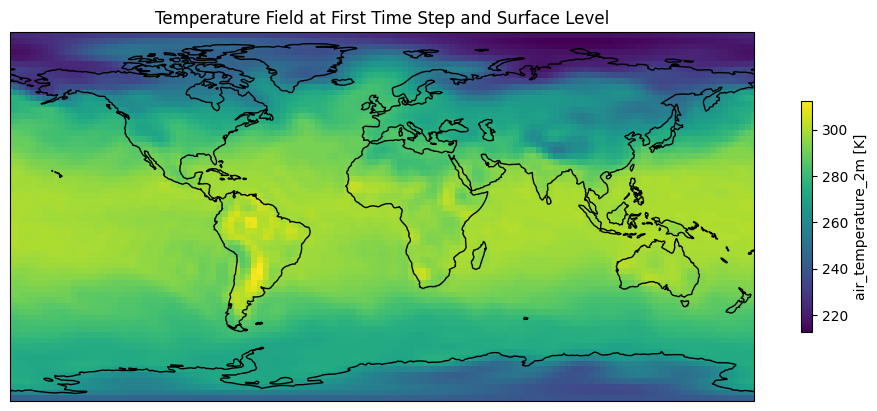

In [4]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ta_field = data['tas'].isel(time=0)  # Selecting the first time and level for simplicity
ta_field.plot(ax=ax, transform=ccrs.PlateCarree(), x='lon', y='lat', cbar_kwargs={'shrink': 0.5})
ax.coastlines()
plt.title('Temperature Field at First Time Step and Surface Level')
plt.show()

In [21]:
# import torch.optim as optim
# import torch.nn.functional as F
# from tqdm.notebook import trange

# # Define a simple linear model
# class SimpleLinearModel(torch.nn.Module):
#     def __init__(self):
#         super(SimpleLinearModel, self).__init__()
#         self.linear = torch.nn.Linear(1, 1)  # Simple linear layer

#     def forward(self, x):
#         return self.linear(x)

# # Instantiate the model
# model = SimpleLinearModel()

# # Define loss function and optimizer
# criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
# optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent

# Dummy dataset (x, y points)
x_train = torch.randn(100, 3)
y_train = torch.randn(100, 1)

from pytorch_lightning import Trainer
from pytorch_lightning import LightningModule

class LitSimpleLinearModel(LightningModule):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(3, 1)

    def forward(self, x):
        return self.linear(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.mse_loss(y_pred, y)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=0.01)

# Prepare data loader
train_data = torch.utils.data.TensorDataset(x_train, y_train)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=1)

# Instantiate the model
lit_model = LitSimpleLinearModel()

# Instantiate the trainer
trainer = Trainer(max_epochs=1000)
trainer.fit(lit_model, train_loader)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-f0aceb06-f990-fd5b-1a44-6e446c8e4434,GPU-e51b7921-2874-1fdc-4b40-5406d9c9136b,GPU-9aee3721-4541-ab23-af70-07a6732c09ae,GPU-bf505f5b-7b14-14df-bb95-5efd0f89c828]

  | Name   | Type   | Params
----------------------------------
0 | linear | Linear | 4     
----------------------------------
4         Trainable params
0         Non-trainable params
4         Total params
0.000     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

In [23]:
# plot the loss
import matplotlib.pyplot as plt

# Assuming 'trainer' has a logger with logged metrics
metrics = trainer.logged_metrics
loss_values = [x['train_loss'].item() for x in metrics]

plt.figure(figsize=(10, 5))
plt.plot(loss_values, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()




TypeError: string indices must be integers, not 'str'